# Main notebook for testing Mean-Reg-MTL

## 0. Load packages



In [11]:
import os, sys, math, copy, torch, scipy, pickle
import numpy as np
import pandas as pd
from numpy import random
from numpy import matlib as mb
import matplotlib.pyplot as plt


BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device

random_seed = 5
random.seed(random_seed)
np.random.seed(random_seed)
random_state = np.random.RandomState(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')

sys.path.append(os.getcwd()+'/assistive_functions')

from household import Household, SyNet
from server.MTL_server import *

# from utils_households import get_lags, connect_to_households
# from load_data import get_data_of_a_person

[INFO] running on GPU core 2


## 1. Load data

In [12]:
exp_name = 'PV_BiModal'  
save = False

# ------ LOAD DATA ------
# NOTE: env generated in notebook 1_visualization
filename_env = config.PVDATA_DIR + '/'+ exp_name+"_env"
file = open(filename_env, 'rb')
env_dict = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict['num_clients'])
print(msg)
file.close()
num_clients = env_dict['num_clients'] 
print('\n'+env_dict['info'])

# ----- SELECT A SUBSET OF CLIENTS -----
clients_subset= [12, 14, 15, 17, 22]
print('Subset of clients for demonstration: ', clients_subset)

num_features = len(env_dict['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict['feature_names'])), *env_dict['feature_names'])
    

[INFO] loaded data for 24 clients

24 households at Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
Subset of clients for demonstration:  [12, 14, 15, 17, 22]

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


# 2. Run

In [13]:
# search space
models_MTL = {
    'sml': {'trained_lambda':None, 'trained_w_0':None}, 
    '1y': {'trained_lambda':None, 'trained_w_0':None}
}
results_MTL = {
    'sml': {'rsmse': {'criterion_train': np.zeros(num_clients), 'criterion_valid': np.zeros(num_clients)}}, 
    '1y': {'rsmse': {'criterion_train': np.zeros(num_clients), 'criterion_valid': np.zeros(num_clients)}}
}
log_lambdas = np.linspace(-3, 3, 40)
lambdas = pow(10, log_lambdas)
lr=0.1
inner_iters=1
outer_iters=100
valid_frac=0.2


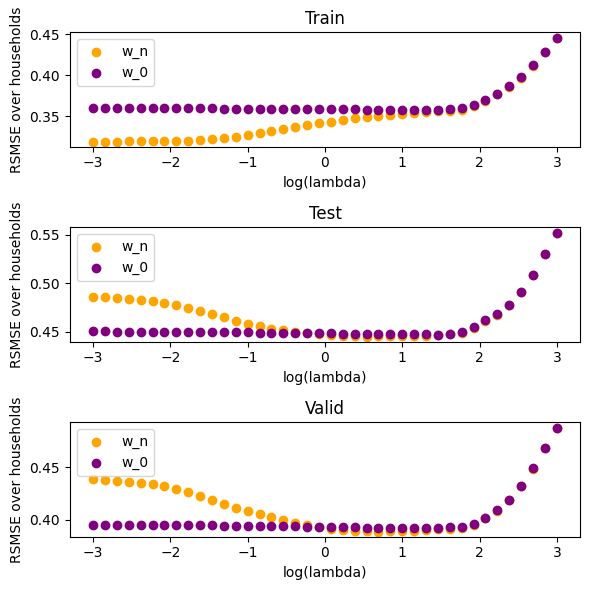

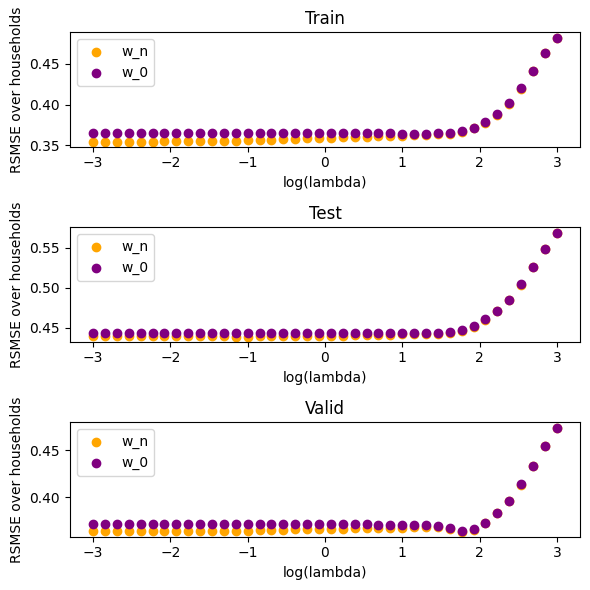

In [14]:
for scenario_name_fl in ['sml', '1y']:
    # 1. define households
    clients_data = env_dict['train_scenarios'][scenario_name_fl]['clients_data']
    clients_ts = env_dict['train_scenarios'][scenario_name_fl]['time_series']
    households = []
    for client_num in np.arange(num_clients):
        h = Household(
            clients_data[client_num], clients_ts[client_num], normalize_data=True, random_seed=random_seed)
        h.train_valid_split(valid_frac=valid_frac)
        households.append(h)

    
    # 2. initialize 
    rsmse_w_n_trn = np.zeros((len(households), len(lambdas)))
    rsmse_w_n_vld = np.zeros((len(households), len(lambdas)))
    rsmse_w_n_tst = np.zeros((len(households), len(lambdas)))
    rsmse_w_0_trn = np.zeros((len(households), len(lambdas)))
    rsmse_w_0_vld = np.zeros((len(households), len(lambdas)))
    rsmse_w_0_tst = np.zeros((len(households), len(lambdas)))


    # 3. grid search lambda
    min_rsmse_vld = 1e4
    for l_ind, lambda_ in enumerate(lambdas): 
        # train
        result = mtl_train(
            households, lr=lr, lambda_=lambda_, 
            inner_iters=inner_iters, outer_iters=outer_iters, 
            optim_method='Adam', verbose=False, priv=False,
            random_seed=random_seed)
        w_0=result['w_0']
        init_state_dict=result['init_state_dicts']
        # predict
        for h_ind, household in enumerate(households): 
            # predict with w_n 
            pred_w_n_trn = household.predict(household.X_train, method='MTL').flatten()
            pred_w_n_vld = household.predict(household.X_valid,  method='MTL').flatten()
            pred_w_n_tst = household.predict(household.X_test,  method='MTL').flatten()
            # predict with w_0
            pred_w_0_trn = household.predict(household.X_train, method='MTL', model=w_0).flatten()
            pred_w_0_vld = household.predict(household.X_valid, method='MTL', model=w_0).flatten()
            pred_w_0_tst = household.predict(household.X_test,  method='MTL', model=w_0).flatten()
            # errors of w_n
            rsmse_w_n_trn[h_ind, l_ind] = (np.mean(
                    (pred_w_n_trn-household.y_train.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_train.detach().numpy().flatten())
            rsmse_w_n_vld[h_ind, l_ind] = (
                    np.mean((pred_w_n_vld-household.y_valid.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_valid.detach().numpy().flatten())
            rsmse_w_n_tst[h_ind, l_ind] = (
                    np.mean((pred_w_n_tst-household.y_test.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_test.detach().numpy().flatten())
            # errors of w_0
            rsmse_w_0_trn[h_ind, l_ind] = (
                    np.mean((pred_w_0_trn-household.y_train.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_train.detach().numpy().flatten())
            rsmse_w_0_vld[h_ind, l_ind] = (
                    np.mean((pred_w_0_vld-household.y_valid.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_valid.detach().numpy().flatten())
            rsmse_w_0_tst[h_ind, l_ind] = (
                    np.mean((pred_w_0_tst-household.y_test.detach().numpy().flatten()
                )**2)**0.5 )/np.std(household.y_test.detach().numpy().flatten())
        # update best_w_0
        if np.mean(rsmse_w_n_vld[:, l_ind].flatten()) < min_rsmse_vld:
            min_rsmse_vld = np.mean(rsmse_w_n_vld[:, l_ind].flatten())
            models_MTL[scenario_name_fl]['trained_w_0'] = w_0
            models_MTL[scenario_name_fl]['trained_lambda'] = lambdas[l_ind]


    # 4. compute error metrics
    rsmse_w_n_trn_av = np.mean(rsmse_w_n_trn, axis=0)
    rsmse_w_n_vld_av = np.mean(rsmse_w_n_vld, axis=0)
    rsmse_w_n_tst_av = np.mean(rsmse_w_n_tst, axis=0)
    rsmse_w_0_trn_av = np.mean(rsmse_w_0_trn, axis=0)
    rsmse_w_0_vld_av = np.mean(rsmse_w_0_vld, axis=0)
    rsmse_w_0_tst_av = np.mean(rsmse_w_0_tst, axis=0)
    rsmse_w_n_trn_sd = np.var(rsmse_w_n_trn, axis=0)**0.5
    rsmse_w_n_vld_sd = np.var(rsmse_w_n_vld, axis=0)**0.5
    rsmse_w_n_tst_sd = np.var(rsmse_w_n_tst, axis=0)**0.5
    rsmse_w_0_trn_sd = np.var(rsmse_w_0_trn, axis=0)**0.5
    rsmse_w_0_vld_sd = np.var(rsmse_w_0_vld, axis=0)**0.5
    rsmse_w_0_tst_sd = np.var(rsmse_w_0_tst, axis=0)**0.5


    # 5. Plot
    xx = log_lambdas
    fig,axs = plt.subplots(3,1,figsize=(6,6))
    axs[0].scatter(xx, rsmse_w_n_trn_av, color='orange', label='w_n')
    axs[0].scatter(xx, rsmse_w_0_trn_av, color='purple', label='w_0')
    #axs[0].fill_between(xx, mse_w_0_trn_av-1.96*mse_w_0_trn_sd, mse_w_0_trn_av+1.96*mse_w_0_trn_sd,alpha=0.2, color='purple')
    axs[0].set_title('Train')
    axs[2].scatter(xx, rsmse_w_n_vld_av, color='orange', label='w_n')
    axs[2].scatter(xx, rsmse_w_0_vld_av, color='purple', label='w_0')
    #axs[2].fill_between(xx, mse_w_0_vld_av-1.96*mse_w_0_vld_sd, mse_w_0_vld_av+1.96*mse_w_0_vld_sd,alpha=0.2, color='purple')
    axs[2].set_title('Valid')
    axs[1].scatter(xx, rsmse_w_n_tst_av, color='orange', label='w_n')
    axs[1].scatter(xx, rsmse_w_0_tst_av, color='purple', label='w_0')
    #axs[1].fill_between(xx, mse_w_0_tst_av-1.96*mse_w_0_tst_sd, mse_w_0_tst_av+1.96*mse_w_0_tst_sd,alpha=0.2, color='purple')
    axs[1].set_title('Test')
    for ax in axs:
        ax.legend()
        ax.set_xlabel('log(lambda)')
        ax.set_ylabel('RSMSE over households')
    plt.tight_layout()
    plt.show()


    # 6. best lambda
    best_l_ind = np.argmin(rsmse_w_n_vld_av)
    assert models_MTL[scenario_name_fl]['trained_lambda'] == lambdas[best_l_ind]


    # 7. results
    results_MTL[scenario_name_fl]['rsmse']['criterion_train'] = (1-valid_frac) * rsmse_w_n_trn[:, best_l_ind].flatten() + valid_frac * rsmse_w_n_vld[:, best_l_ind].flatten()
    results_MTL[scenario_name_fl]['rsmse']['criterion_valid'] = rsmse_w_n_tst[:, best_l_ind].flatten() # this is called valid in other notebooks


In [15]:
run_cell = False
if run_cell:

    plt.rc('font', family='serif')
    plt.rc('xtick', labelsize='x-small')
    plt.rc('ytick', labelsize='x-small')

    ## convergence 
    # params
    log_lambda = 1.1
    lambda_ = pow(10, log_lambda)
    inner_iters=1
    outer_iters = 50
    # train
    result = mtl_train(households, lr=lr, lambda_=lambda_, 
            inner_iters=inner_iters, outer_iters=outer_iters, 
            optim_method='Adam', verbose=False)
    g_norm=result['g_norm']
    g_clipped_norm=result['g_clipped_norm']

    fig,ax = plt.subplots(figsize=(8,6))
    for hh_num, household in enumerate(households):
        ax.plot(np.arange(1,outer_iters+1), g_norm[:][hh_num])

    ax.set_xlabel('iteration', fontsize=16)
    ax.set_ylabel('norm of update', fontsize=16)
    ax.set_title('Norm of Update from Households - Not Private', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    plt.tight_layout()
    # plt.savefig('output/norm_update_allhh.png')
    plt.show() 

# New Clients

In [16]:
exp_name_ptc = exp_name
exp_name_new = exp_name_ptc + '_NewClients'


# ----- SET UP LOGGER -----
filename_env_new = config.PVDATA_DIR + '/'+ exp_name_ptc +"_new_clients_env"
filename_res_new = os.path.join(os.getcwd(), "saved_results", exp_name_new)


# ------ LOAD META_TEST DATA ------
file = open(filename_env_new, 'rb')
env_dict_new = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_new['num_clients'])
print(msg)
file.close()
num_clients_new = env_dict_new['num_clients'] 
print('\n'+env_dict_new['info'])


for scenario_name in env_dict_new['train_scenarios'].keys():
    print(scenario_name + ' has {:3.0f} train and {:3.0f} validation samples'.format(
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][0].shape[0],
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][2].shape[0]))
num_features = len(env_dict_new['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict_new['feature_names'])), *env_dict_new['feature_names'])

# visualize_env(env_dict_new, num_days=5, year=2018, scenario_name='1y')


clients_data_new = env_dict_new['train_scenarios']['sml']['clients_data']
clients_ts_new = env_dict_new['train_scenarios']['sml']['time_series']
households_new = []
for client_num in np.arange(num_clients_new):
    h = Household(
        clients_data_new[client_num], clients_ts_new[client_num], normalize_data=True, random_seed=random_seed)
    h.train_valid_split(valid_frac=0.2)
    households_new.append(h)

[INFO] loaded data for 24 clients

24 households at Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
sml has 150 train and 610 validation samples
1y has 610 train and 610 validation samples
5y has 3050 train and 610 validation samples
14y has 8540 train and 610 validation samples

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


In [17]:
results_new = {
    'sml': {'rsmse': {'criterion_train': np.zeros((len(households))), 'criterion_valid': np.zeros((len(households)))}},
    '1y': {'rsmse': {'criterion_train': np.zeros((len(households))), 'criterion_valid': np.zeros((len(households)))}}
}

for scenario_name_fl in ['sml', '1y']:
    # train
    mtl_employ(
        households_new, lr=lr, num_iters=inner_iters*outer_iters, 
        trained_lambda=models_MTL[scenario_name_fl]['trained_lambda'], 
        trained_w_0=models_MTL[scenario_name_fl]['trained_w_0'],
        random_seed=random_seed
    )
    
    # evaluate
    for h_ind, household in enumerate(households_new): 
        # predict with w_n 
        pred_w_n_trn = household.predict(household.X_train, method='MTL').flatten()
        pred_w_n_vld = household.predict(household.X_valid,  method='MTL').flatten()
        pred_w_n_tst = household.predict(household.X_test,  method='MTL').flatten()
        rsmse_trn = (np.mean((pred_w_n_trn-household.y_train.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_train.detach().numpy().flatten())
        rsmse_vld = (np.mean((pred_w_n_vld-household.y_valid.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_valid.detach().numpy().flatten())
        rsmse_tst = (np.mean((pred_w_n_tst-household.y_test.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_test.detach().numpy().flatten())
        results_new[scenario_name_fl]['rsmse']['criterion_train'][h_ind] = (1-valid_frac)*rsmse_trn + valid_frac*rsmse_vld
        results_new[scenario_name_fl]['rsmse']['criterion_valid'][h_ind] = rsmse_tst
                

In [18]:
print('--- results with random seed = {:2.0f} ---'.format(random_seed))
for scenario_name_fl in ['sml', '1y']:
    print('\nexisting - ', scenario_name_fl, ': ', np.mean(results_MTL[scenario_name_fl]['rsmse']['criterion_valid']))
    print('new - ', scenario_name_fl, ': ', np.mean(results_new[scenario_name_fl]['rsmse']['criterion_valid']))

--- results with random seed =  5 ---

existing -  sml :  0.4451800920346521
new -  sml :  0.4400961464769073

existing -  1y :  0.44614641671272254
new -  1y :  0.4473213705370877


In [19]:
filename_save = os.path.join(BASE_DIR, 'experiments', 'PV', 'saved_results', exp_name, 'MTL', 'MTL')
if save:
    file = open(filename_save, 'wb')
    pickle.dump({'results': results_MTL, 'models':models_MTL, 'results_new':results_new}, file)
    file.close()
    print('models saved.')
else:
    file = open(filename_save, 'rb')
    res = pickle.load(file)
    file.close()
    results_new = res['results_new']
    results = res['results']
    # print(results, results_new)

models saved.


In [28]:
# results over seeds 5, 10, 15, 20, 25
# Bi-modal, sml
# existing:[0.4257355618097296, 0.42568561166358987, 0.4259234271200179, 0.42675086035511245, 0.4258778512630479]
# new:     [0.4224890040921965, 0.4225321332483138,  0.4225426771027229, 0.4233890561613494, 0.42260111979131837]

# Bi-modal, 1y
# existing:[0.41354202059752293, 0.41361989800498994, 0.41361671588496707, 0.413711901362152, 0.41365156647174656]
# new:     [0.42961146603698674, 0.4295647017101752,  0.4294588427302908,  0.4294392076215219, 0.42948156601729764] 

# Uni-modal, sml
# existing:[0.4451800920346521, 0.44499762485636735, 0.4448149505907492, 0.4451833216181718, 0.444900388727071, ]
# new:     [0.4400961464769073, 0.4392530360017371 , 0.43906559899868114, 0.44041092035628093, 0.4389254795292648]

# Uni-modal, 1y
# existing:[0.44614641671272254, 0.43962371173266973, 0.4394875304020304, 0.4395229386033684, 0.4396259143742413]
# new:     [0.4473213705370877,  0.4491200148172485,  0.44897873641950176, 0.4490947459744383, 0.45106014876453004]

a = [0.4473213705370877,  0.4491200148172485,  0.44897873641950176, 0.4490947459744383, 0.45106014876453004]
print('{:1.3f}, {:1.3f}'.format(np.mean(a), 1.96*np.std(a)))

0.449, 0.002
